In [1]:
#import sys
#print(sys.executable)

### Data Wrangling : Orders

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

# Load dataset
data_path = Path("data/raw/orders.csv")
if not data_path.exists():
    data_path = Path("../data/raw/orders.csv")  

df = pd.read_csv(data_path)
df.head()
                               

,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,region,status
0,ORD10001,C1011,P039,2022-12-25,3,22.99,0.0,South,Completed
1,ORD10002,C1045,P003,2023-08-11,1,54.99,0.0,West,Completed
2,ORD10003,C1122,P010,2023-09-29,2,39.99,0.0,North,Returned
3,ORD10004,C1194,P012,2023-11-05,3,44.99,0.0,North,Completed
4,ORD10005,C1170,P022,2023-12-21,3,11.99,0.0,North,Completed


In [3]:
# Shape of dataset
df.shape

(5015, 9)

In [4]:
# Check datatypes
df.dtypes

order_id           str
customer_id        str
product_id         str
order_date         str
quantity         int64
unit_price     float64
discount       float64
region             str
status             str
dtype: object

In [5]:
# Statistical summary
df.describe()

,quantity,unit_price,discount
count,5015.000000,5015.000000,4955.000000
mean,1.957129,65.449629,0.028880
std,1.192299,52.257106,0.059777
min,-1.000000,6.990000,0.000000
25%,1.000000,29.990000,0.000000
50%,2.000000,49.990000,0.000000
75%,3.000000,89.990000,0.000000
max,5.000000,210.000000,0.200000


In [6]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [7]:
df['order_date'].dtypes

dtype('<M8[us]')

In [8]:
# Check null values
df.isnull().sum()


order_id        0
customer_id     0
product_id      0
order_date      0
quantity        0
unit_price      0
discount       60
region          0
status          0
dtype: int64

In [9]:
# Check for duplicate values
print("Duplicate values",df.duplicated().sum())

Duplicate values 15


In [10]:
df[df.duplicated(keep=False)]

,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,region,status
601,ORD10602,C1180,P032,2023-11-26,1,34.99,0.00,West,Completed
603,ORD10604,C1089,P008,2022-05-14,1,89.99,0.00,West,Completed
626,ORD10627,C1144,P026,2023-02-24,1,19.99,0.00,North,Completed
999,ORD11000,C1108,P004,2022-12-08,1,79.99,0.00,South,Completed
1915,ORD11916,C1102,P028,2022-08-25,1,59.99,0.00,East,Returned
1962,ORD11963,C1011,P005,2023-10-22,4,99.99,0.05,South,Completed
2710,ORD12711,C1186,P022,2022-03-08,1,11.99,0.00,North,Completed
2759,ORD12760,C1053,P034,2023-09-20,2,39.99,0.20,East,Completed
3113,ORD13114,C1002,P003,2022-03-20,1,54.99,0.00,West,Returned
3859,ORD13860,C1032,P021,2022-04-18,3,7.99,0.00,East,Completed


In [11]:
# Drop duplicates
df = df.drop_duplicates()

In [12]:
# Discount column imputation
df['discount'] = df['discount'].fillna(0)

In [13]:
# Primary key uniqueness 
df['order_id'].duplicated().sum()


np.int64(0)

In [14]:
# Status and Region
print("Status",df['status'].unique())
print("Region",df['region'].unique())

Status <ArrowStringArray>
['Completed', 'Returned']
Length: 2, dtype: str
Region <ArrowStringArray>
['South', 'West', 'North', 'East']
Length: 4, dtype: str


In [15]:
# Datset correctness by status and quantity
df.loc[(df['status'] == 'Completed') & (df['quantity'] < 0), 'status'] = 'Returned'

In [16]:
df[(df['status'] == 'Completed') & (df['quantity'] < 0)]

,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,region,status


In [17]:
# Quantity check
print(df[df['quantity'] <= 0])

# Unique categories
print(df['status'].value_counts())
print(df['region'].value_counts())

      order_id customer_id product_id order_date  quantity  unit_price  \
410   ORD10411       C1102       P039 2023-11-03        -1       22.99   
762   ORD10763       C1018       P030 2022-08-16        -1      109.99   
1616  ORD11617       C1185       P011 2022-02-13        -1      159.99   
1698  ORD11699       C1065       P001 2022-02-05        -1       19.99   
3219  ORD13220       C1194       P023 2023-02-27        -1       22.99   
3227  ORD13228       C1150       P018 2022-02-24        -1       14.99   
4322  ORD14323       C1002       P005 2022-09-13        -1       99.99   
4570  ORD14571       C1185       P009 2023-03-06        -1       49.99   
4701  ORD14702       C1194       P001 2022-05-10        -1       19.99   
4949  ORD14950       C1063       P015 2022-10-28        -1       24.99   

      discount region    status  
410       0.20   East  Returned  
762       0.00  North  Returned  
1616      0.00   West  Returned  
1698      0.00   West  Returned  
3219      0.00 

In [18]:
# Revenue 
df['revenue'] = df['quantity'] * df['unit_price'] * (1 - df['discount'])
print(df['revenue'].head())

0     68.97
1     54.99
2     79.98
3    134.97
4     35.97
Name: revenue, dtype: float64


In [19]:
df['revenue'].describe()

count    5000.000000
mean      124.001463
std       137.496562
min      -159.990000
25%        39.990000
50%        79.980000
75%       159.980000
max      1050.000000
Name: revenue, dtype: float64

##### Note:

- Checked consistency between order status and quantity, and corrected cases where completed orders had negative quantities.
- Handled missing values in the discount column by replacing them with 0.
- Created a revenue column using quantity, unit price, and discount.
- Verified that returns are reflected as negative revenue and overall data behaves consistently.

#### Insights

In [20]:
# Top performing products
df.groupby('product_id')['revenue'].sum().sort_values(ascending=False).head(10)

# Insight: Product P007 generates highest revenue, indicating strong demand.

product_id
P007    77290.5000
P011    66083.8695
P006    53796.3615
P029    41517.9240
P008    35694.5335
P005    35326.4670
P004    29124.3590
P014    24922.7305
P030    23295.8820
P012    19071.2610
Name: revenue, dtype: float64

In [21]:
# Return rate analysis
return_rate = (df['status'] == 'Returned').mean() * 100
print(return_rate)

8.1


Return Rate is 8%.

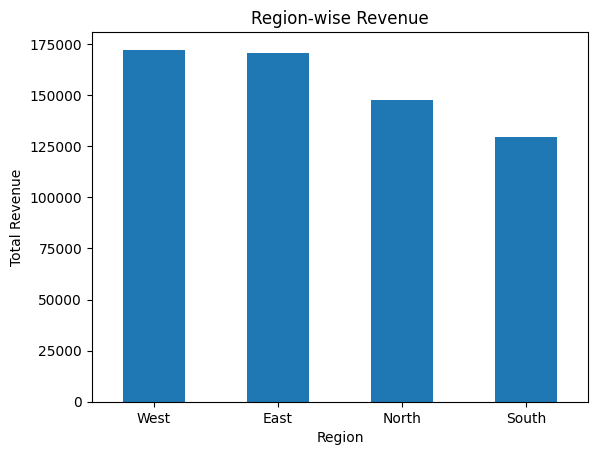

In [22]:
# Region wise revenue
region_revenue = df.groupby('region')['revenue'].sum().sort_values(ascending=False)

plt.figure()
region_revenue.plot(kind='bar')
plt.title('Region-wise Revenue')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

In [23]:
# Calculate region revenue statistics for insight
total_region_revenue = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
top_region = total_region_revenue.index[0]
top_region_value = total_region_revenue.iloc[0]
total_revenue = total_region_revenue.sum()
top_region_percent = (top_region_value / total_revenue) * 100
revenue_variance = (total_region_revenue.std() / total_region_revenue.mean()) * 100

print(f"Top Region: {top_region}")
print(f"Top Region Revenue: ${top_region_value:,.2f}")
print(f"Top Region % of Total: {top_region_percent:.2f}%")
print(f"Revenue Variance Across Regions: {revenue_variance:.2f}%")


Top Region: West
Top Region Revenue: $172,181.04
Top Region % of Total: 27.77%
Revenue Variance Across Regions: 13.14%


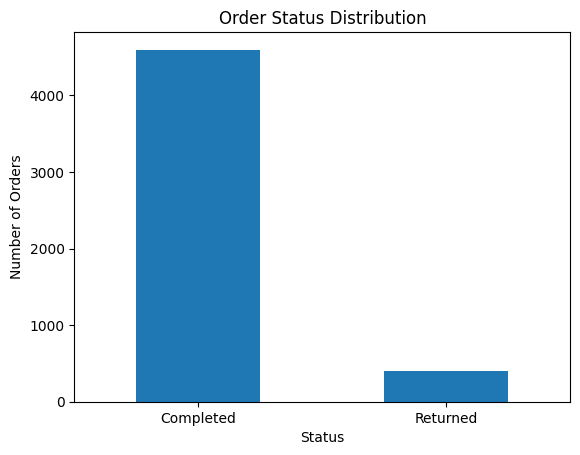

In [24]:
# Completed vs Returned Status
status_counts = df['status'].value_counts()

plt.figure()
status_counts.plot(kind='bar')
plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

In [25]:
# Calculate status distribution statistics for insight
status_dist = df['status'].value_counts()
total_orders = status_dist.sum()
completed_count = status_dist.get('Completed', 0)
returned_count = status_dist.get('Returned', 0)
completed_rate = (completed_count / total_orders) * 100
returned_rate = (returned_count / total_orders) * 100

print(f"Total Orders: {total_orders}")
print(f"Completed Orders: {completed_count} ({completed_rate:.2f}%)")
print(f"Returned Orders: {returned_count} ({returned_rate:.2f}%)")
print(f"Order Fulfillment Success Rate: {completed_rate:.2f}%")


Total Orders: 5000
Completed Orders: 4595 (91.90%)
Returned Orders: 405 (8.10%)
Order Fulfillment Success Rate: 91.90%


In [26]:
# Save dataset
output_path = Path("data/processed/orders_enriched.csv")
if not output_path.parent.exists():
    output_path = Path("../data/processed/orders_enriched.csv")

output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)